In [5]:
# Install requiremets
%pip install azure-ai-vision-imageanalysis scikit-learn

  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 27.7 MB/s  0:00:00m0:00:010:02
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn] [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


Detection succes analysis

In [6]:
from azure.cognitiveservices.vision.computervision import ComputerVisionClient
from azure.cognitiveservices.vision.computervision.models import OperationStatusCodes
from azure.cognitiveservices.vision.computervision.models import VisualFeatureTypes
from azure.ai.vision.imageanalysis.models import VisualFeatures

from msrest.authentication import CognitiveServicesCredentials
from array import array
import os
from PIL import Image
import sys
import time
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
from skimage import io
import numpy as np

In [7]:
subscription_key = os.environ["VISION_KEY"]
endpoint = os.environ["VISION_ENDPOINT"]
computervision_client = ComputerVisionClient(endpoint, CognitiveServicesCredentials(subscription_key))

In [8]:
from pathlib import Path
paths = ["bike1.jpg", "bike02.jpg", "bike03.jpg", "bike04.jpg", "bike05.jpg", "bike06.jpg", "bike07.jpg", "bike08.jpg", "bike09.jpg", "bike10.jpg",
         "traffic01.jpg", "traffic02.jpg", "traffic03.jpg", "traffic04.jpg", "traffic05.jpg", "traffic06.jpg", "traffic07.jpg", "traffic08.jpg", "traffic09.jpg", "traffic10.jpg",]

labelNames = ["true", "false"]
expected = ["true" for i in range(10)]
expected.extend(["false" for i in range(10)])
predicted = []

for path in paths:
    img = open(Path("images/" + path), "rb")
    found = 0
    result = computervision_client.analyze_image_in_stream(img, visual_features=[VisualFeatureTypes.objects])
    for ob in result.objects:
        print(f"Detected: {ob.object_property} with confidence {ob.confidence}")
    for ob in result.objects:
        if ob.object_property == "bike" or ob.object_property == "bicycle":
            predicted.append("true")
            found = 1
            break
    if found == 0:
        predicted.append("false")

Detected: bicycle with confidence 0.936
Detected: Wheel with confidence 0.521
Detected: bicycle with confidence 0.913
Detected: car with confidence 0.58
Detected: person with confidence 0.791
Detected: person with confidence 0.876
Detected: bicycle with confidence 0.803
Detected: bicycle with confidence 0.825
Detected: bicycle with confidence 0.751
Detected: car with confidence 0.634
Detected: person with confidence 0.734
Detected: person with confidence 0.801
Detected: cycle with confidence 0.591
Detected: person with confidence 0.8
Detected: bicycle with confidence 0.859
Detected: person with confidence 0.918
Detected: bicycle with confidence 0.777
Detected: Gondola with confidence 0.516
Detected: bicycle with confidence 0.823
Detected: person with confidence 0.527
Detected: car with confidence 0.796
Detected: car with confidence 0.713
Detected: stop sign with confidence 0.762
Detected: car with confidence 0.58
Detected: car with confidence 0.882


In [9]:
cm = confusion_matrix(expected, predicted, labels=labelNames)
print(f"confusion matrix: {cm[0][0]} TN, {cm[1][0]} FN, {cm[0][1]} FP, {cm[1][1]} TP")
acc = accuracy_score(expected, predicted)
print("accuracy: ", acc)
precision = precision_score(expected, predicted, average= None, labels=labelNames)
print("precision: ", precision)
recall = recall_score(expected, predicted, average= None, labels=labelNames)
print("recall: ", recall)


confusion matrix: 8 TN, 0 FN, 2 FP, 10 TP
accuracy:  0.9
precision:  [1.         0.83333333]
recall:  [0.8 1. ]


In [10]:
bike1 = [4.0,30.0,410.0,410.0]
bike2 = [14.0,86.0,381.0,320.0]
bike3 = [64.0, 146.0, 200.0, 394.0]
bike3_1 = [153.0, 145.0, 346.0, 408.0]
bike4 = [0.0, 0.0, 416.0, 416.0]
bike5 = [67.0, 48.0, 358.0, 344.0]
bike6 = [67.0, 140.0, 200.0, 396.0]
bike6_1 = [155.0, 140.0, 346.0, 405.0]
bike7 = [55.0, 198.0, 300.0, 415.0]
bike8 = [51.0, 0.0, 388.0, 359.0]
bike9 = [3.0, 6.0, 382.0, 383.0]
bike10 = [139.0, 122.0, 376.0, 406.0]
bikes = [bike1, bike2, bike4, bike5, bike7, bike8, bike9, bike10]

In [11]:
def IoU(predicted1, bike):
    x1_1 = predicted1[0]
    y1_1 = predicted1[1]
    x2_1 = predicted1[2] + predicted1[0]
    y2_1 = predicted1[3] + predicted1[1]

    area1 = predicted1[2] * predicted1[3]

    x1_2 = bike[0]
    y1_2 = bike[1]
    x2_2 = bike[2]
    y2_2 = bike[3]

    area2 = (x2_2 - x1_2) * (y2_2 - y1_2)

    inner_x1 = max(x1_1, x1_2)
    inner_y1 = max(y1_1, y1_2)
    inner_x2 = min(x2_1, x2_2)
    inner_y2 = min(y2_1, y2_2)

    inner_area = (inner_x2 - inner_x1) * (inner_y2 - inner_y1)
    union_area = area1 + area2 - inner_area

    print("IoU: ", inner_area / union_area)

detection error:  113.5
IoU:  0.9573926749655591


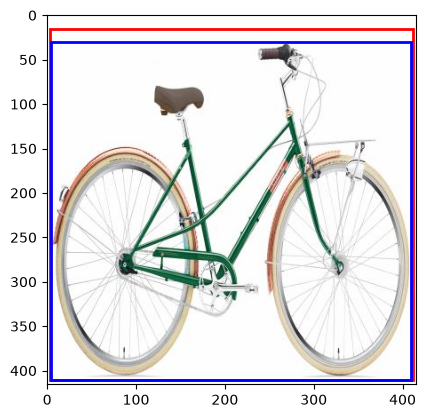

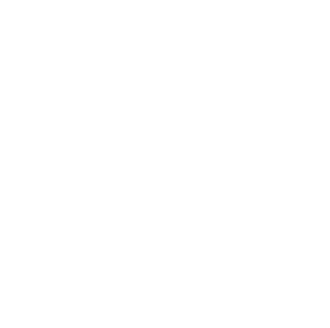

detection error:  9618.75
IoU:  0.9264747954454425


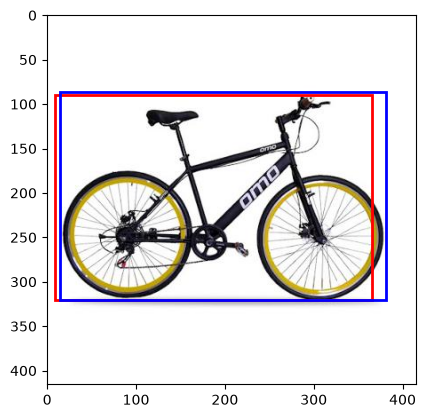

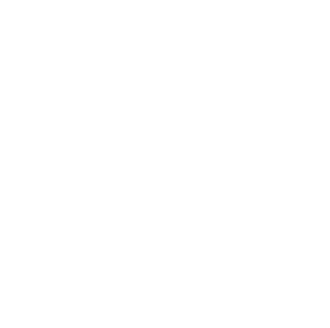

detection error:  204.0
IoU:  0.9808385724852071


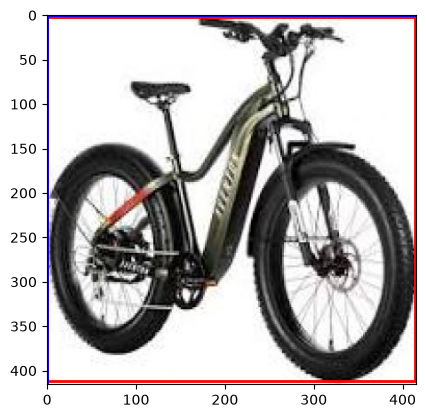

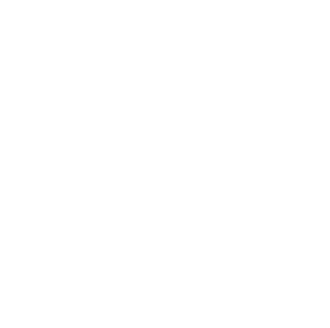

detection error:  8082.5
IoU:  0.9010788363263897


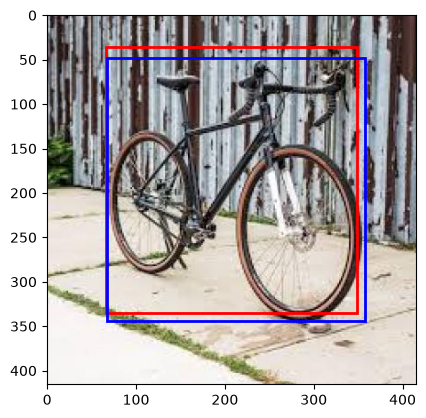

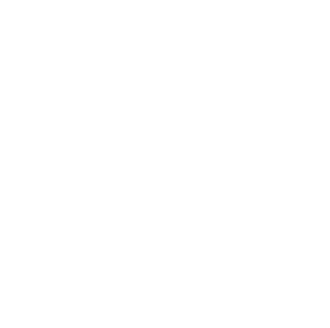

detection error:  24148.5
IoU:  0.9155193992490613


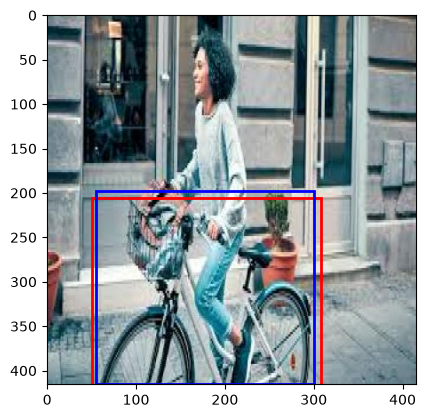

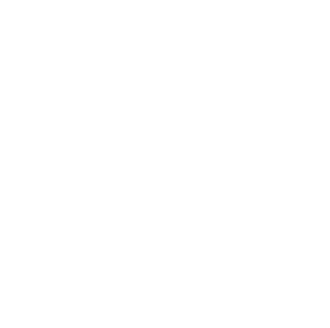

detection error:  24148.5
IoU:  0.2899094608941843


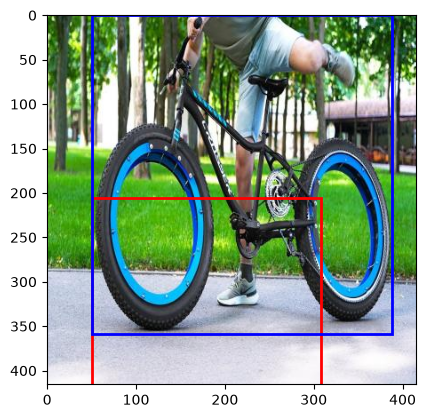

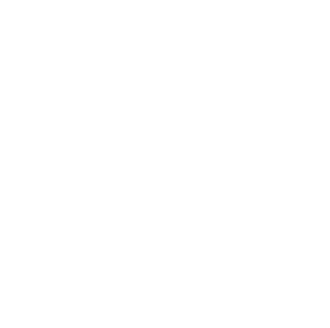

detection error:  647.25
IoU:  0.9036875400384369


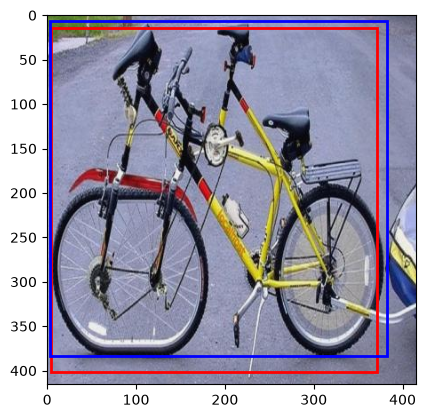

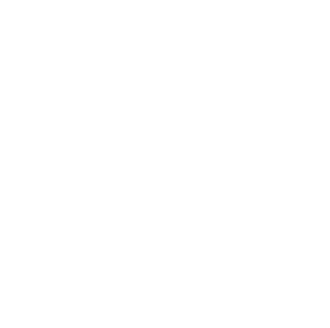

detection error:  18377.75
IoU:  0.8902558230464168


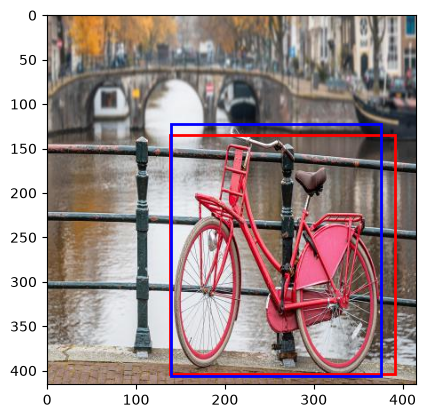

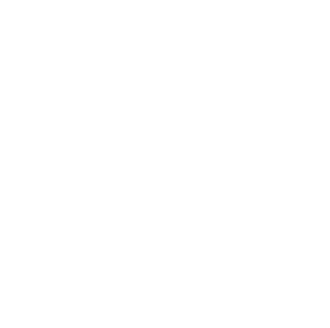

In [12]:
image_paths = ["images/bike1.jpg", "images/bike02.jpg", "images/bike04.jpg", "images/bike05.jpg", "images/bike07.jpg", "images/bike08.jpg", "images/bike09.jpg", "images/bike10.jpg"]

for idx, path in enumerate(image_paths):
    bike = bikes[idx]
    img1 = open(path, "rb")
    result = computervision_client.analyze_image_in_stream(img1, visual_features=[VisualFeatureTypes.objects])
    for ob in result.objects:
        if ob.object_property == "bike" or ob.object_property == "bicycle":
            predicted1 = [ob.rectangle.x, ob.rectangle.y, ob.rectangle.w, ob.rectangle.h]

    err = 0
    for v in zip(predicted1, bike1):
        err = err + (v[0] - v[1])**2
    err /= 4
    print("detection error: ", err)

    IoU(predicted1, bike)

    img = plt.imread(path)
    fig = plt.imshow(img)
    fig.axes.add_patch(plt.Rectangle(xy = (predicted1[0], predicted1[1]), width = predicted1[2], height = predicted1[3], fill = False, color = "red", linewidth = 2))
    fig.axes.add_patch(plt.Rectangle(xy = (bike[0], bike[1]), width = bike[2] - bike[0], height = bike[3] - bike[1], fill = False, color = "blue", linewidth = 2))
    plt.figure(figsize=(4, 4))
    plt.axis("off")
    plt.show()

detection error for bike 1:  12743.25
IoU:  0.9085285368112059
Bike 2 is not detected


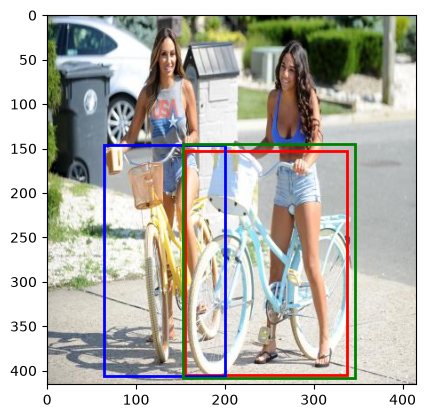

In [13]:
img = open("images/bike03.jpg", "rb")
result = computervision_client.analyze_image_in_stream(img, visual_features=[VisualFeatureTypes.objects])
ok = 0
predicted2 = []
for ob in result.objects:
    if ob.object_property == "bicycle" and ok == 0:
        predicted1 = [ob.rectangle.x, ob.rectangle.y, ob.rectangle.w, ob.rectangle.h]
        ok = 1
    else:
        if ob.object_property == "bicycle" and ok == 1:
            predicted2 = [ob.rectangle.x, ob.rectangle.y, ob.rectangle.w, ob.rectangle.h]

err1 = 0
for v in zip(predicted1, bike3_1):
    err1 = err1 + (v[0] - v[1])**2
err1 /= 4
print("detection error for bike 1: ", err1)

IoU(predicted1, bike3_1)

if not predicted2:
    print("Bike 2 is not detected")

im = plt.imread("images/bike03.jpg")
fig = plt.imshow(im)
fig.axes.add_patch(plt.Rectangle(xy = (predicted1[0], predicted1[1]), width = predicted1[2], height = predicted1[3], fill = False, color = "red", linewidth = 2))
fig.axes.add_patch(plt.Rectangle(xy = (bike3[0], bike3[1]), width = bike3[2] - bike3[0], height= bike[3] - bike3[1], fill = False, color = "blue", linewidth = 2))
fig.axes.add_patch(plt.Rectangle(xy = (bike3_1[0], bike3_1[1]), width = bike3_1[2] - bike3_1[0], height= bike3_1[3] - bike3_1[1], fill = False, color = "green", linewidth = 2))

if predicted2:
    err2 = 0
    for v in zip(predicted2, bike3_1):
        err2 = err2 + (v[0] - v[1])**2
    err2 /= 4
    print("detection error for bike 2: ", err2)

    IoU(predicted2, bike3_1)

    fig.axes.add_patch(plt.Rectangle(xy = (predicted2[0], predicted2[1]), width = predicted2[2], height = predicted2[3], fill = False, color = "pink", linewidth = 2))
plt.show()

detection error for bike 1:  12536.75
IoU:  0.911113306332115
Bike 2 is not detected


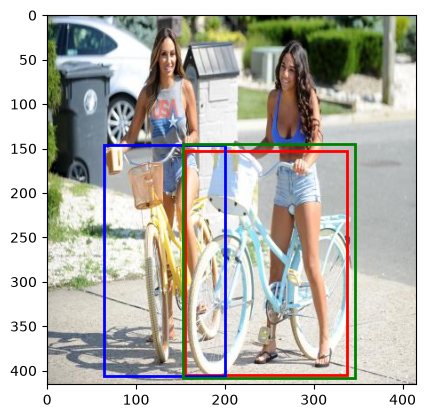

In [14]:
img = open("images/bike06.jpg", "rb")
result = computervision_client.analyze_image_in_stream(img, visual_features=[VisualFeatureTypes.objects])
ok = 0
predicted2 = []
for ob in result.objects:
    if ob.object_property == "bicycle" and ok == 0:
        predicted1 = [ob.rectangle.x, ob.rectangle.y, ob.rectangle.w, ob.rectangle.h]
        ok = 1
    else:
        if ob.object_property == "bicycle" and ok == 1:
            predicted2 = [ob.rectangle.x, ob.rectangle.y, ob.rectangle.w, ob.rectangle.h]

err1 = 0
for v in zip(predicted1, bike6_1):
    err1 = err1 + (v[0] - v[1])**2
err1 /= 4
print("detection error for bike 1: ", err1)

IoU(predicted1, bike6_1)

if not predicted2:
    print("Bike 2 is not detected")

im = plt.imread("images/bike03.jpg")
fig = plt.imshow(im)
fig.axes.add_patch(plt.Rectangle(xy = (predicted1[0], predicted1[1]), width = predicted1[2], height = predicted1[3], fill = False, color = "red", linewidth = 2))
fig.axes.add_patch(plt.Rectangle(xy = (bike3[0], bike3[1]), width = bike3[2] - bike3[0], height= bike[3] - bike3[1], fill = False, color = "blue", linewidth = 2))
fig.axes.add_patch(plt.Rectangle(xy = (bike3_1[0], bike3_1[1]), width = bike3_1[2] - bike3_1[0], height= bike3_1[3] - bike3_1[1], fill = False, color = "green", linewidth = 2))

if predicted2:
    err2 = 0
    for v in zip(predicted2, bike6_1):
        err2 = err2 + (v[0] - v[1])**2
    err2 /= 4
    print("detection error for bike 2: ", err2)

    IoU(predicted2, bike6_1)

    fig.axes.add_patch(plt.Rectangle(xy = (predicted2[0], predicted2[1]), width = predicted2[2], height = predicted2[3], fill = False, color = "pink", linewidth = 2))
plt.show()